In [1]:
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset


class FrameCSVDataset(Dataset):
    """
    PyTorch Dataset that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (T, 3, H, W) float32 in [0,1]
      y: int64 sparse label: 0=Left, 1=None, 2=Right
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        seq_len=128,
        max_none_per_epoch=0,   # 0 => exclude None, -1 => include all
        mask_boxes=None,        # list of (xmin,ymin,xmax,ymax)
        image_size=(224, 224),
        shuffle=True,
        debug_zero_right=False,
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.image_size = tuple(image_size)
        self.shuffle = bool(shuffle)
        self.debug_zero_right = debug_zero_right

        # Load CSV
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort to preserve temporal order
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Label indices: 0=Left, 1=None, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int64)
        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]
            none = 1 if (l == r) else 0
            if l == 1 and r == 0:
                self.y_idx[i] = 0
            elif none == 1:
                self.y_idx[i] = 1
            else:
                self.y_idx[i] = 2

        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Epoch sampling (call this once per epoch from training loop)
    # ------------------------------------------------------------------
    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none

        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def on_epoch_start(self):
        """Call this at the start of each epoch."""
        self._build_epoch_indices()

    # ------------------------------------------------------------------
    # Dataset API
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.epoch_indices)

    def _load_frame(self, index):
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for xmin, ymin, xmax, ymax in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            im = im.resize((self.image_size[1], self.image_size[0]))

            x = np.asarray(im, dtype=np.float32) / 255.0
            x = torch.from_numpy(x).permute(2, 0, 1)  # (3,H,W)

        return x
    
    def __getitem__(self, idx):
        cur_idx = self.epoch_indices[idx]

        T = self.seq_len
        C, H, W = 3, self.image_size[0], self.image_size[1]

        label = int(self.y_idx[cur_idx])  # 0=Left, 1=None, 2=Right

        # --------------------------------------------------
        # DEBUG MODE: zero-out RIGHT class frames
        # --------------------------------------------------
        if self.debug_zero_right and label == 2:
            X = torch.zeros((T, C, H, W), dtype=torch.float32)
            y = torch.tensor(label, dtype=torch.long)
            return X, y

        # --------------------------------------------------
        # Normal path
        # --------------------------------------------------
        X = torch.zeros((T, C, H, W), dtype=torch.float32)

        seq_start = cur_idx - (T - 1)

        for t in range(T):
            src_idx = seq_start + t
            if src_idx < 0:
                continue
            X[t] = self._load_frame(src_idx)

        y = torch.tensor(label, dtype=torch.long)
        return X, y


    # def __getitem__(self, idx):
    #     cur_idx = self.epoch_indices[idx]

    #     T = self.seq_len
    #     C, H, W = 3, self.image_size[0], self.image_size[1]

    #     X = torch.zeros((T, C, H, W), dtype=torch.float32)

    #     seq_start = cur_idx - (T - 1)

    #     for t in range(T):
    #         src_idx = seq_start + t
    #         if src_idx < 0:
    #             continue
    #         X[t] = self._load_frame(src_idx)

    #     y = torch.tensor(self.y_idx[cur_idx], dtype=torch.long)

    #     return X, y


In [20]:
# --- Paths ---
train_csv_path  = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224_controls_extracted.csv"
train_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224"

train_csv_path2  = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_controls_extracted.csv"
train_frames_dir2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224"

val_csv_path   = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224_controls_extracted.csv"
val_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224"

# --- Settings ---
image_size = (224, 224)
batch_size = 1
seq_len = 128
max_none_per_epoch = 18000
debug_zero_right = False

mask_boxes = [
    (2, 103, 58, 147),      # left HUD region
    (165, 103, 221, 147),   # right HUD region
]
mask_boxes = None  # disable masking

# --- PyTorch Datasets (replace FrameCSVSequence) ---
train_ds1 = FrameCSVDataset(
    csv_path=train_csv_path,
    frames_dir=train_frames_dir,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=True,
    debug_zero_right=debug_zero_right
)

train_ds2 = FrameCSVDataset(
    csv_path=train_csv_path2,
    frames_dir=train_frames_dir2,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=True,
    debug_zero_right=debug_zero_right
)

val_ds = FrameCSVDataset(
    csv_path=val_csv_path,
    frames_dir=val_frames_dir,
    seq_len=seq_len,
    max_none_per_epoch=max_none_per_epoch,   # typical for validation: include all classes
    mask_boxes=mask_boxes,
    image_size=image_size,
    shuffle=False,           # typical for validation: deterministic
    debug_zero_right=debug_zero_right
)

# --- DataLoaders ---
# IMPORTANT:
# - Use shuffle=False here because the dataset already performs epoch sampling/shuffling internally.
# - Call dataset.on_epoch_start() at the start of every epoch for train_ds1/train_ds2.
train_loader1 = torch.utils.data.DataLoader(train_ds1, batch_size=batch_size, shuffle=False)
train_loader2 = torch.utils.data.DataLoader(train_ds2, batch_size=batch_size, shuffle=False)
val_loader    = torch.utils.data.DataLoader(val_ds,  batch_size=batch_size, shuffle=False)

# --- Example per-epoch hook (call in your training loop) ---
# for epoch in range(num_epochs):
#     train_ds1.on_epoch_start()
#     train_ds2.on_epoch_start()
#     # val_ds.on_epoch_start()  # usually not needed for val
#     ...


In [3]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import torch


def visualize_random_sequence_torch(
    dataset_or_loader,
    max_frames_to_show=32,
    max_cols=8,
    figsize_per_cell=(2.5, 2.5),
    cls_map=None,
    denorm=None,
):
    """
    Visualize a random temporal sample from a PyTorch Dataset or DataLoader.

    Works with:
      - Dataset returning: X (T,C,H,W) and y (int) or (1,)
      - DataLoader returning: X (B,T,C,H,W) and y (B,)

    Args:
      dataset_or_loader: torch.utils.data.Dataset or DataLoader
      max_frames_to_show: cap frames visualized
      max_cols: max columns in grid
      figsize_per_cell: per-cell size for matplotlib
      cls_map: {0:"L", 1:"N", 2:"R"} mapping
      denorm: optional callable to undo normalization per frame tensor
              signature: denorm(frame_t: torch.Tensor) -> torch.Tensor (C,H,W)
              (If you used mean/std normalization in model pipeline)

    Notes:
      - Assumes pixel range [0,1] unless denorm is provided.
      - The supervised label corresponds to the LAST frame in the sequence.
    """
    if cls_map is None:
        cls_map = {0: "L", 1: "N", 2: "R"}

    # -----------------------------
    # Sample retrieval
    # -----------------------------
    if hasattr(dataset_or_loader, "__iter__") and not hasattr(dataset_or_loader, "__getitem__"):
        # Treat as DataLoader-like
        loader = dataset_or_loader
        batch = next(iter(loader))
        X, y = batch

        # X: (B,T,C,H,W) expected
        if isinstance(X, torch.Tensor) and X.ndim == 5:
            B = X.shape[0]
            sample_idx = random.randint(0, B - 1)
            frames = X[sample_idx]  # (T,C,H,W)
            y_s = y[sample_idx]
            batch_info = "batch=0"
        else:
            raise ValueError("Expected DataLoader to yield X with shape (B,T,C,H,W).")
    else:
        # Treat as Dataset-like
        ds = dataset_or_loader
        idx = random.randint(0, len(ds) - 1)
        frames, y_s = ds[idx]  # frames: (T,C,H,W)
        sample_idx = idx
        batch_info = f"idx={idx}"

        if not (isinstance(frames, torch.Tensor) and frames.ndim == 4):
            raise ValueError("Expected Dataset to return X with shape (T,C,H,W).")

    # -----------------------------
    # Label extraction (sparse)
    # -----------------------------
    if isinstance(y_s, torch.Tensor):
        label_idx = int(y_s.reshape(-1)[0].item())
    else:
        label_idx = int(np.asarray(y_s).reshape(-1)[0])

    label_str = cls_map.get(label_idx, str(label_idx))

    # -----------------------------
    # Frame indexing
    # -----------------------------
    T = frames.shape[0]
    if T <= max_frames_to_show:
        idxs = list(range(T))
    else:
        idxs = np.linspace(0, T - 1, max_frames_to_show, dtype=int).tolist()

    n_imgs = len(idxs)
    cols = min(max_cols, n_imgs)
    rows = math.ceil(n_imgs / cols)

    fig_w = cols * figsize_per_cell[0]
    fig_h = rows * figsize_per_cell[1]

    plt.figure(figsize=(fig_w, fig_h))

    # -----------------------------
    # Plot frames
    # -----------------------------
    for i, t in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)

        fr = frames[t]  # (C,H,W)
        if denorm is not None:
            fr = denorm(fr)

        # convert to numpy HWC for imshow
        fr = fr.detach().cpu()
        fr = fr.permute(1, 2, 0).numpy()  # (H,W,C)

        # clamp in case of minor numeric drift
        fr = np.clip(fr, 0.0, 1.0)

        plt.imshow(fr)
        plt.axis("off")

        if t == T - 1:
            plt.title(f"t={t}  \u2190 {label_str}", fontsize=9, color="red")
        else:
            plt.title(f"t={t}", fontsize=8)

    plt.suptitle(
        f"Random temporal sample | {batch_info}, sample={sample_idx} | Target = {label_str}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


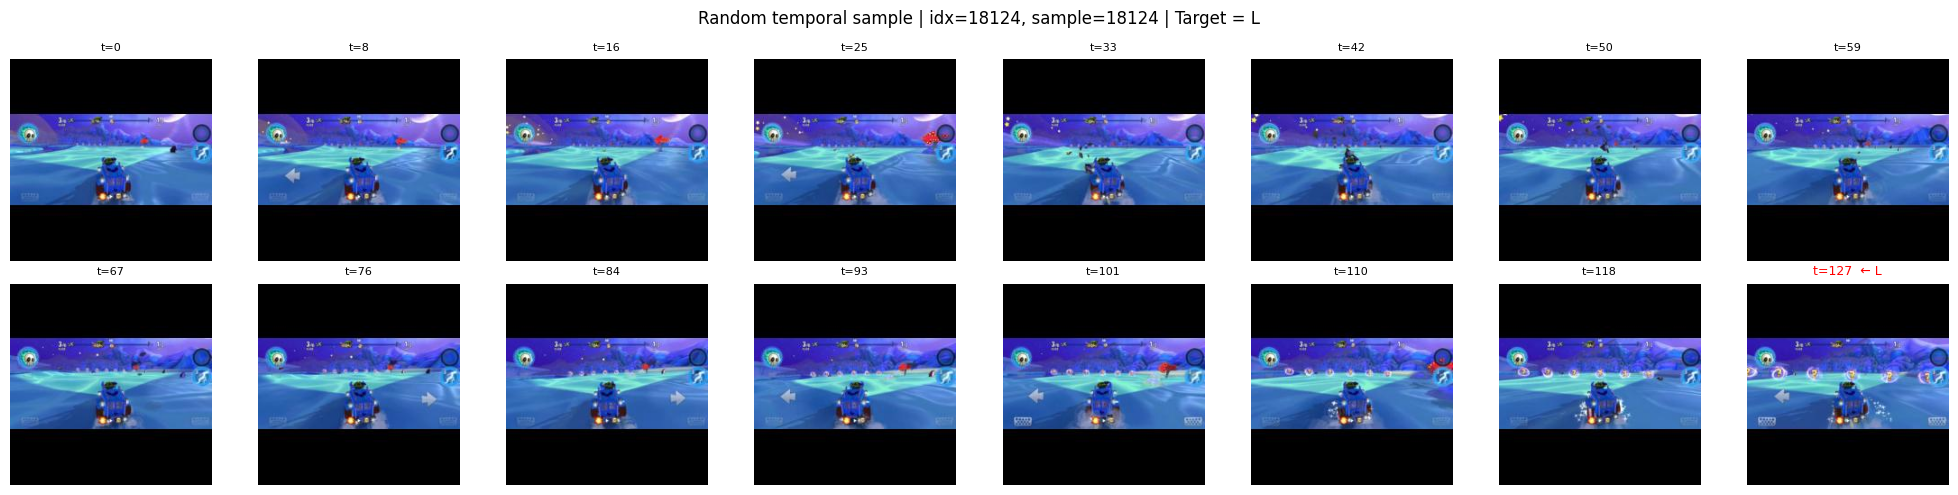

In [10]:
visualize_random_sequence_torch(train_ds1, max_frames_to_show=16)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FrameCNN(nn.Module):
    """
    Per-frame CNN feature extractor that mirrors your Keras frame_cnn() block.

    Input:  (B, 3, H, W)
    Output: (B, 256)
    """
    def __init__(self, in_ch=3, dropout=0.2):
        super().__init__()

        # Block 1
        self.conv1a = nn.Conv2d(in_ch, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)

        # GAP
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # FC head (512 -> 256)
        self.fc1 = nn.Linear(128, 512)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 256)

    def forward(self, x):
        # x: (B,3,H,W)
        x = self.conv1a(x)
        x = self.conv1b(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = self.conv2b(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        x = self.bn3a(x)
        x = F.relu(x)
        x = self.conv3b(x)
        x = self.bn3b(x)
        x = F.relu(x)

        x = self.gap(x)              # (B,128,1,1)
        x = x.flatten(1)             # (B,128)
        x = F.relu(self.fc1(x))      # (B,512)
        x = self.drop(x)
        x = F.relu(self.fc2(x))      # (B,256)
        return x


class CNNLSTM3Class(nn.Module):
    """
    Mirrors your Keras model:

      Input:  (B, T, 3, H, W)
      Frame CNN -> (B,T,256)
      LSTM -> (B,lstm_units) using last output
      Dense 128 + Dropout
      Classifier -> logits (B,n_classes)

    Use CrossEntropyLoss (expects logits).
    """
    def __init__(
        self,
        seq_len=128,
        image_size=(224, 224),
        n_classes=3,
        lstm_units=256,
        dropout=0.2,
        bidirectional=False,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.image_size = image_size
        self.n_classes = n_classes
        self.lstm_units = lstm_units
        self.bidirectional = bidirectional

        self.frame_cnn = FrameCNN(in_ch=3, dropout=dropout)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_units,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0,  # PyTorch LSTM dropout works only when num_layers > 1
        )

        lstm_out_dim = lstm_units * (2 if bidirectional else 1)

        self.fc_mid = nn.Linear(lstm_out_dim, 128)
        self.drop = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,T,3,H,W)
        B, T, C, H, W = x.shape

        # Flatten time into batch for CNN: (B*T,3,H,W)
        x = x.reshape(B * T, C, H, W)
        feats = self.frame_cnn(x)          # (B*T,256)

        # Restore time: (B,T,256)
        feats = feats.reshape(B, T, 256)

        # LSTM over time
        out, (h_n, c_n) = self.lstm(feats)

        # Last time-step output (equivalent to return_sequences=False)
        last = out[:, -1, :]               # (B, lstm_out_dim)

        x = F.relu(self.fc_mid(last))      # (B,128)
        x = self.drop(x)
        logits = self.fc_out(x)            # (B,n_classes)
        return logits


# ---- Build model (equivalent to your build_cnn_lstm_for_frames) ----
seq_len = seq_len  # keep your existing variable
model = CNNLSTM3Class(
    seq_len=seq_len,
    image_size=(224, 224),
    n_classes=3,
    lstm_units=256,
    dropout=0.2,
    bidirectional=False,
)
print(model)


CNNLSTM3Class(
  (frame_cnn): FrameCNN(
    (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3b): BatchNorm2d(128

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN3D3Class(nn.Module):
    """
    3D CNN for video/frame sequences.

    Input:  X (B, T, 3, H, W) in [0,1]
    Output: logits (B, n_classes)

    Uses Conv3D over (T,H,W). Internally converts to (B,3,T,H,W).
    """
    def __init__(
        self,
        n_classes=3,
        dropout=0.2,
        base_channels=32,
        temporal_pool=True,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4

        # Block 1
        self.conv1a = nn.Conv3d(3, c1, kernel_size=3, padding=1)
        self.conv1b = nn.Conv3d(c1, c1, kernel_size=3, padding=1)
        #self.bn1 = nn.BatchNorm3d(c1)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))  # downsample spatial only

        # Block 2
        self.conv2a = nn.Conv3d(c1, c2, kernel_size=3, padding=1)
        self.conv2b = nn.Conv3d(c2, c2, kernel_size=3, padding=1)
        #self.bn2 = nn.BatchNorm3d(c2)
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))  # spatial only

        # Block 3
        self.conv3a = nn.Conv3d(c2, c3, kernel_size=3, padding=1)
        self.conv3b = nn.Conv3d(c3, c3, kernel_size=3, padding=1)
        #self.bn3 = nn.BatchNorm3d(c3)

        # Optional temporal pooling: only makes sense if T > 1
        self.temporal_pool = temporal_pool
        if temporal_pool:
            self.pool_t = nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))  # downsample time only

        # Global average pool over (T,H,W)
        self.gap = nn.AdaptiveAvgPool3d((1, 1, 1))

        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(c3, 128)
        self.fc_out = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: (B,T,3,H,W) -> (B,3,T,H,W)
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        x = self.conv1a(x)
        x = self.conv1b(x)
        #x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2a(x)
        x = self.conv2b(x)
        #x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3a(x)
        x = self.conv3b(x)
        #x = self.bn3(x)
        x = F.relu(x)

        # If you use seq_len=1, keep temporal_pool=False
        if self.temporal_pool and x.shape[2] >= 2:
            x = self.pool_t(x)

        x = self.gap(x).flatten(1)   # (B, c3)
        x = self.drop(F.relu(self.fc1(x)))
        logits = self.fc_out(x)
        return logits


# --- Build + loss/optimizer ---
model = CNN3D3Class(
    n_classes=3,
    dropout=0.2,
    base_channels=32,
    temporal_pool=True,  # set False if seq_len == 1
)


In [18]:

# ---- Loss + optimizer (equivalent compile) ----
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # ~L2
criterion = nn.CrossEntropyLoss()  # sparse labels (0/1/2), logits input

In [14]:
import time
import sys


def keras_progress_bar(
    step,
    total_steps,
    loss,
    acc,
    elapsed,
    bar_width=30,
    prefix="",
    eta=None,
):
    frac = step / total_steps
    filled = int(bar_width * frac)
    bar = "=" * filled + ">" + "." * (bar_width - filled - 1)

    msg = (
        f"\r{prefix}"
        f"{step}/{total_steps} "
        f"[{bar}] "
        f"- {elapsed:.0f}s"
    )

    if eta is not None:
        msg += f" - ETA: {eta}"

    msg += f" - loss: {loss:.4g} - accuracy: {acc:.4f}"
    sys.stdout.write(msg)
    sys.stdout.flush()


In [15]:
import torch
import numpy as np
import time


def train_model(
    model,
    train_loaders,   # list of train loaders (e.g. [train_loader1, train_loader2])
    val_loader,
    optimizer,
    criterion,
    epochs=10,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # -------------------------
        # TRAIN
        # -------------------------
        model.train()

        for ds in train_loaders:
            if hasattr(ds.dataset, "on_epoch_start"):
                ds.dataset.on_epoch_start()

        total_steps = sum(len(dl) for dl in train_loaders)
        step = 0

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        start_time = time.time()

        for loader in train_loaders:
            for X, y in loader:
                step += 1

                X = X.to(device)          # (B,T,3,H,W)
                y = y.to(device)          # (B,)

                optimizer.zero_grad()
                logits = model(X)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                # stats
                running_loss += loss.item() * y.size(0)
                preds = logits.argmax(dim=1)
                running_correct += (preds == y).sum().item()
                running_total += y.size(0)

                elapsed = time.time() - start_time
                acc = running_correct / max(1, running_total)

                # ETA
                steps_left = total_steps - step
                if step > 1:
                    sec_per_step = elapsed / step
                    eta = time.strftime("%M:%S", time.gmtime(steps_left * sec_per_step))
                else:
                    eta = None

                keras_progress_bar(
                    step=step,
                    total_steps=total_steps,
                    loss=running_loss / max(1, running_total),
                    acc=acc,
                    elapsed=elapsed,
                    eta=eta,
                )

        print()  # newline after epoch progress

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # -------------------------
        # VALIDATION
        # -------------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)

                logits = model(X)
                loss = criterion(logits, y)

                val_loss += loss.item() * y.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        epoch_time = time.time() - start_time

        # -------------------------
        # Epoch summary (Keras style)
        # -------------------------
        print(
            f"{total_steps}/{total_steps} "
            f"[==============================] "
            f"- {epoch_time:.0f}s "
            f"- loss: {train_loss:.4g} "
            f"- accuracy: {train_acc:.4f} "
            f"- val_loss: {val_loss:.4g} "
            f"- val_accuracy: {val_acc:.4f}"
        )


In [21]:
train_model(
    model=model,
    train_loaders=[train_loader1],
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,
)



Epoch 1/100
28965/49215 [=================>............] - 30149s - ETA: 51:17 - loss: 1.11 - accuracy: 0.33947

KeyboardInterrupt: 

In [43]:
#save the model
torch.save(model.state_dict(), "data\cnn_lstm_model.pth")